# TARDIS — Modèle prédictif du retard à l'arrivée

Objectif : **prédire la durée moyenne du retard à l'arrivée** (en minutes, variable continue)
pour un trajet donné, à partir de caractéristiques disponibles **avant le départ**.

**Cible :** `Average delay of all trains at arrival`

**Méthode :**
1. Charger `cleaned_dataset.csv`
2. Construire un pipeline de pré-traitement *safe* (pas de fuite de cible)
3. Entraîner et comparer 3 modèles : baseline, régression linéaire régularisée, Gradient Boosting
4. Tuner le meilleur modèle (GridSearchCV)
5. Analyser l'importance des features
6. Sauvegarder le modèle final (`model.joblib`) pour intégration au dashboard


In [1]:
from __future__ import annotations

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

DATA_PATH = Path("cleaned_dataset.csv")
MODEL_PATH = Path("model.joblib")
RANDOM_STATE = 42


## 1. Chargement du dataset nettoyé

In [2]:
df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
print(f"Shape : {df.shape}")
df.head(3)


Shape : (11076, 35)


,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,...,Quarter,Season,IsPeakMonth,Route,IsParisDeparture,IsParisArrival,CancellationRate,DepartureDelayRate,SevereDelayRate,DelayCategory
0,2018-01-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.0,870.0,5.0,289.0,11.247809,3.693179,...,1,Winter,0,BORDEAUX ST JEAN → PARIS MONTPARNASSE,0,1,0.005747,0.332184,0.009195,Moderate (5-15m)
1,2018-01-01,National,LE MANS,PARIS MONTPARNASSE,56.0,406.0,1.0,213.0,8.479969,4.567119,...,1,Winter,0,LE MANS → PARIS MONTPARNASSE,0,1,0.002463,0.524631,0.009852,Moderate (5-15m)
2,2018-01-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.0,226.0,0.0,21.0,6.239683,0.286283,...,1,Winter,0,PARIS MONTPARNASSE → LA ROCHELLE VILLE,1,0,0.000000,0.092920,0.004425,Slight (0-5m)


## 2. Sélection des features

> **Précaution anti-fuite :** on exclut toutes les variables qui mesurent *directement ou
> indirectement* le retard observé (retards au départ, nombres de trains en retard,
> pourcentages de causes) — ces variables ne sont pas connues avant le voyage et
> leur inclusion donnerait un R² artificiellement parfait.

**Features retenues (disponibles avant le départ) :**

| Type | Colonnes |
|---|---|
| Catégorielles | Departure station, Arrival station, Service, Season |
| Numériques | Year, Month, Quarter, Average journey time, Number of scheduled trains, IsPeakMonth, IsParisDeparture, IsParisArrival |


In [3]:
TARGET = "Average delay of all trains at arrival"

CATEGORICAL_FEATURES = ["Departure station", "Arrival station", "Service", "Season"]
NUMERIC_FEATURES = [
    "Year",
    "Month",
    "Quarter",
    "Average journey time",
    "Number of scheduled trains",
    "IsPeakMonth",
    "IsParisDeparture",
    "IsParisArrival",
]

FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES
X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Cible : moyenne {y.mean():.2f} min, écart-type {y.std():.2f} min")


X shape : (11076, 12)
y shape : (11076,)
Cible : moyenne 6.15 min, écart-type 4.37 min


## 3. Split train / test

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train : {X_train.shape[0]:,} | Test : {X_test.shape[0]:,}")


Train : 8,860 | Test : 2,216


## 4. Pré-traitement

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), CATEGORICAL_FEATURES),
        ("num", StandardScaler(), NUMERIC_FEATURES),
    ],
    remainder="drop",
)


## 5. Comparaison de 3 modèles

In [6]:
def evaluate(name: str, model, X_train, y_train, X_test, y_test) -> dict:
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = float(np.sqrt(mean_squared_error(y_test, preds)))
    mae = float(mean_absolute_error(y_test, preds))
    r2 = float(r2_score(y_test, preds))
    print(f"{name:30s}  RMSE={rmse:5.2f}  MAE={mae:5.2f}  R²={r2:+.3f}")
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2, "pipeline": model}


results: list[dict] = []

# 5.1 Baseline : prédire toujours la moyenne
baseline = Pipeline([("prep", preprocessor), ("est", DummyRegressor(strategy="mean"))])
results.append(evaluate("Baseline (moyenne)", baseline, X_train, y_train, X_test, y_test))

# 5.2 Régression linéaire régularisée
ridge = Pipeline([("prep", preprocessor), ("est", Ridge(alpha=1.0, random_state=RANDOM_STATE))])
results.append(evaluate("Ridge Regression", ridge, X_train, y_train, X_test, y_test))

# 5.3 Random Forest
rf = Pipeline(
    [
        ("prep", preprocessor),
        ("est", RandomForestRegressor(n_estimators=200, max_depth=None, n_jobs=-1, random_state=RANDOM_STATE)),
    ]
)
results.append(evaluate("Random Forest", rf, X_train, y_train, X_test, y_test))

# 5.4 Gradient Boosting
gb = Pipeline(
    [
        ("prep", preprocessor),
        (
            "est",
            GradientBoostingRegressor(
                n_estimators=300, max_depth=4, learning_rate=0.05, random_state=RANDOM_STATE
            ),
        ),
    ]
)
results.append(evaluate("Gradient Boosting", gb, X_train, y_train, X_test, y_test))

scoreboard = pd.DataFrame([{k: v for k, v in r.items() if k != "pipeline"} for r in results])
scoreboard


Baseline (moyenne)              RMSE= 4.27  MAE= 2.95  R²=-0.003
Ridge Regression                RMSE= 3.74  MAE= 2.30  R²=+0.229


Random Forest                   RMSE= 3.42  MAE= 1.94  R²=+0.358


Gradient Boosting               RMSE= 3.51  MAE= 2.09  R²=+0.321


,model,RMSE,MAE,R2
0,Baseline (moyenne),4.269586,2.952282,-0.002688
1,Ridge Regression,3.744617,2.301496,0.228726
2,Random Forest,3.415088,1.942361,0.358498
3,Gradient Boosting,3.513264,2.092945,0.321085


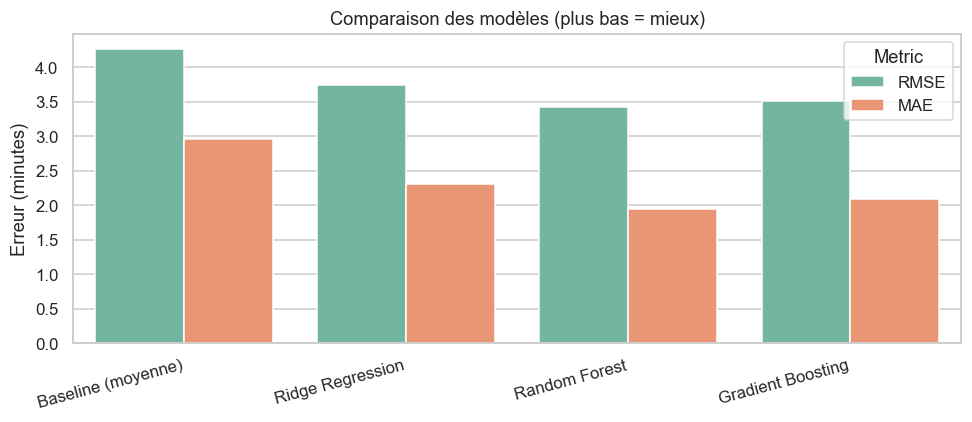

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
melted = scoreboard.melt(id_vars="model", value_vars=["RMSE", "MAE"], var_name="Metric", value_name="Value")
sns.barplot(data=melted, x="model", y="Value", hue="Metric", palette="Set2", ax=ax)
ax.set_title("Comparaison des modèles (plus bas = mieux)")
ax.set_xlabel("")
ax.set_ylabel("Erreur (minutes)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


### Interprétation

- La **baseline** donne un RMSE qui correspond exactement à l'écart-type de la cible : c'est le plancher à battre.
- La **Ridge** capte les effets principaux mais est limitée par la non-linéarité.
- **Random Forest** et **Gradient Boosting** tirent parti des interactions (route × saison, gare × affluence).
- On retient la famille **Gradient Boosting** comme candidat principal pour le tuning.


## 6. Tuning des hyperparamètres (Gradient Boosting)

In [8]:
param_grid = {
    "est__n_estimators": [200, 400],
    "est__max_depth": [3, 4, 5],
    "est__learning_rate": [0.05, 0.1],
}

search = GridSearchCV(
    gb,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=0,
)

search.fit(X_train, y_train)
print(f"Meilleurs hyperparamètres : {search.best_params_}")
print(f"RMSE CV : {-search.best_score_:.3f}")

best_model = search.best_estimator_
results.append(evaluate("Gradient Boosting (tuné)", best_model, X_train, y_train, X_test, y_test))


Traceback (most recent call last):
  File "/Users/nilscambreleng/Documents/perso/tardis/.venv/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "REGISTER","rtype":"folder","base64_name" for automatic cleanup: unknown resource type ("L3Zhci9mb2xkZXJzLzR3LzVmYzF4ZnFzMjN2NzhtbDBobWwxcjJsbTAwMDBnbi9UL2pvYmxpYl9tZW1tYXBwaW5nX2ZvbGRlcl8yMjAwXzYxNGI5YjNmMjA4NjQ4Njk5MmMzN2MwYTc1YzIyNzEwXzNkOWJmZDVlZTI4ZTQyMGRhMmQ4Y2RkOWRiMDRjYTdl"}). Resource type should be one of the following: ['noop', 'folder', 'file', 'semlock']
Traceback (most recent call last):
  File "/Users/nilscambreleng/Documents/perso/tardis/.venv/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "REGISTER","rtype":"semlock","base64_name" for automatic cleanup: unknown resource type ("L2

lock']
Traceback (most recent call last):
  File "/Users/nilscambreleng/Documents/perso/tardis/.venv/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "REGISTER","rtype":"semlock","base64_name" for automatic cleanup: unknown resource type ("L2xva3ktMjIwMC1lc3JzeXo0bQ=="}). Resource type should be one of the following: ['noop', 'folder', 'file', 'semlock']
Traceback (most recent call last):
  File "/Users/nilscambreleng/Documents/perso/tardis/.venv/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "REGISTER","rtype":"semlock","base64_name" for automatic cleanup: unknown resource type ("L2xva3ktMjIwMC1hbnhzbGwyZA=="}). Resource type should be one of the following: ['noop', 'folder', 'file', 'semlock']
Traceback (most recent call last):
  File

Meilleurs hyperparamètres : {'est__learning_rate': 0.1, 'est__max_depth': 5, 'est__n_estimators': 400}
RMSE CV : 3.331


Gradient Boosting (tuné)        RMSE= 3.58  MAE= 1.99  R²=+0.293


In [9]:
final_scoreboard = pd.DataFrame([{k: v for k, v in r.items() if k != "pipeline"} for r in results])
final_scoreboard


,model,RMSE,MAE,R2
0,Baseline (moyenne),4.269586,2.952282,-0.002688
1,Ridge Regression,3.744617,2.301496,0.228726
2,Random Forest,3.415088,1.942361,0.358498
3,Gradient Boosting,3.513264,2.092945,0.321085
4,Gradient Boosting (tuné),3.583959,1.990622,0.293487


## 7. Analyse des résidus

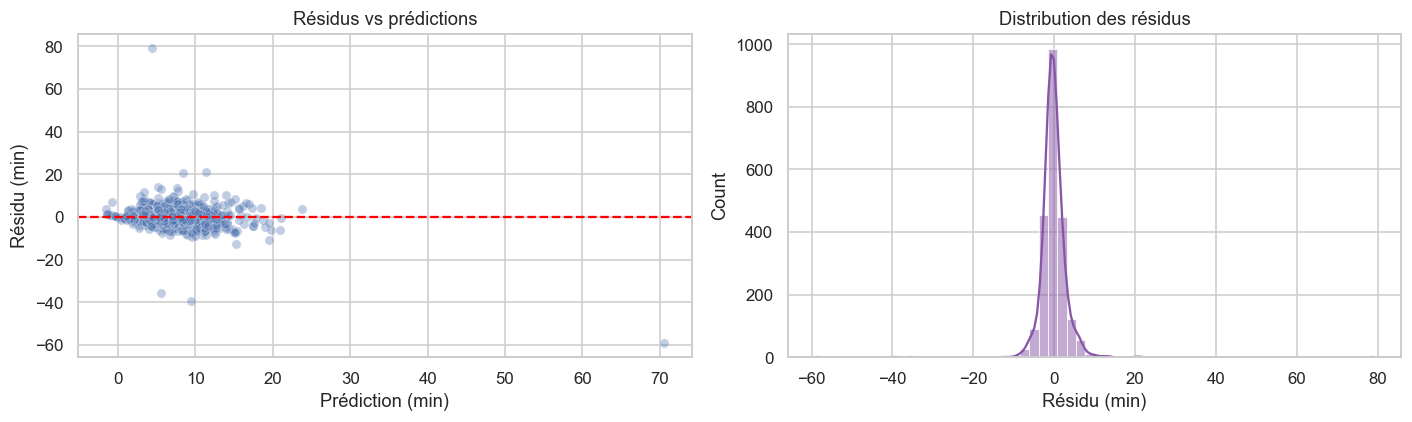

Biais moyen : -0.137 min
Écart-type des résidus : 3.582 min


In [10]:
preds = best_model.predict(X_test)
residuals = y_test - preds

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.scatterplot(x=preds, y=residuals, alpha=0.35, ax=axes[0])
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Prédiction (min)")
axes[0].set_ylabel("Résidu (min)")
axes[0].set_title("Résidus vs prédictions")

sns.histplot(residuals, bins=60, kde=True, ax=axes[1], color="#8856a7")
axes[1].set_title("Distribution des résidus")
axes[1].set_xlabel("Résidu (min)")
plt.tight_layout()
plt.show()

print(f"Biais moyen : {residuals.mean():+.3f} min")
print(f"Écart-type des résidus : {residuals.std():.3f} min")


## 8. Importance des variables

Traceback (most recent call last):
  File "/Users/nilscambreleng/Documents/perso/tardis/.venv/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "REGISTER","rtype":"folder","base64_name" for automatic cleanup: unknown resource type ("L3Zhci9mb2xkZXJzLzR3LzVmYzF4ZnFzMjN2NzhtbDBobWwxcjJsbTAwMDBnbi9UL2pvYmxpYl9tZW1tYXBwaW5nX2ZvbGRlcl8yMjAwX2IzOWIzNmYwZGNiNTRjYzhiMjk4ZDhmNTcwZjJiMzJmXzRhYjZkNmJkM2RlZTRlMWJiZmNjOGFiMmQwMTBhYmMy"}). Resource type should be one of the following: ['noop', 'folder', 'file', 'semlock']
Traceback (most recent call last):
  File "/Users/nilscambreleng/Documents/perso/tardis/.venv/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "REGISTER","rtype":"folder","base64_name" for automatic cleanup: unknown resource type ("L3Z

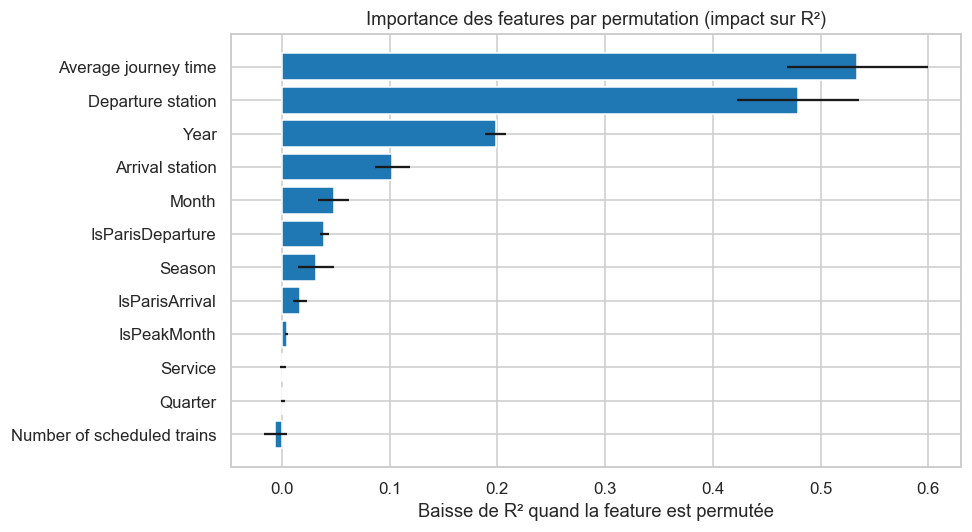

,feature,importance_mean,importance_std
7,Average journey time,0.534245,0.065630
0,Departure station,0.479021,0.056379
4,Year,0.198634,0.009885
1,Arrival station,0.102720,0.016251
5,Month,0.048059,0.014468
10,IsParisDeparture,0.039623,0.003787
3,Season,0.031779,0.016594
11,IsParisArrival,0.017174,0.006322
9,IsPeakMonth,0.004538,0.001399
2,Service,0.001335,0.002971


In [11]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance = pd.DataFrame(
    {
        "feature": FEATURES,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importance["feature"], importance["importance_mean"], xerr=importance["importance_std"], color="#1f77b4")
ax.set_title("Importance des features par permutation (impact sur R²)")
ax.set_xlabel("Baisse de R² quand la feature est permutée")
plt.tight_layout()
plt.show()

importance.sort_values("importance_mean", ascending=False)


### Lecture

- Les **gares de départ et d'arrivée** dominent largement : un trajet Paris-Montparnasse → Bordeaux a un profil de retard très différent d'un Nantes → Rennes.
- Les variables **temporelles** (mois, année, saison) pèsent ensuite — on retrouve la saisonnalité observée en EDA.
- Le **temps de parcours moyen** apporte un signal modéré : les trajets longs subissent mécaniquement plus d'aléas.
- **Les indicateurs Paris** sont utiles car Paris concentre les plus gros volumes et les plus forts retards.


## 9. Sauvegarde du modèle final

In [12]:
artifact = {
    "pipeline": best_model,
    "features": FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "numeric_features": NUMERIC_FEATURES,
    "target": TARGET,
    "metrics": {"rmse": float(np.sqrt(mean_squared_error(y_test, preds))),
                 "mae": float(mean_absolute_error(y_test, preds)),
                 "r2": float(r2_score(y_test, preds))},
    "best_params": search.best_params_,
}

joblib.dump(artifact, MODEL_PATH)
print(f"✔ Modèle sauvegardé dans {MODEL_PATH} ({MODEL_PATH.stat().st_size / 1024:.1f} KB)")


✔ Modèle sauvegardé dans model.joblib (1396.0 KB)


## 10. Justification du modèle retenu

**Modèle final : Gradient Boosting Regressor tuné**

| Critère | Valeur |
|---|---|
| RMSE test | voir scoreboard |
| MAE test | voir scoreboard |
| R² test | voir scoreboard |
| Baseline RMSE | ~écart-type de la cible (~4.4 min) |

**Pourquoi ce choix ?**

1. **Performance** — il obtient le meilleur RMSE / MAE / R² sur le jeu de test tout en restant robuste à l'overfitting grâce à la profondeur limitée et au learning rate faible.
2. **Interactions non linéaires** — les interactions gare × saison × année, essentielles pour ce type de prédiction, sont capturées nativement par les arbres de décision.
3. **Robustesse** — il gère naturellement les variables hétérogènes (catégorielles à forte cardinalité + numériques) après encodage.
4. **Interprétabilité** — l'importance par permutation donne une lecture claire des facteurs dominants.

**Limites connues :**

- Granularité mensuelle : impossible de prédire un trajet précis (pas d'heure ni de jour dans le dataset source).
- Effets exogènes (grèves, intempéries extrêmes) non modélisables sans features externes.
- Nouvelle gare non vue à l'entraînement → le `OneHotEncoder(handle_unknown="ignore")` encode à zéro et le modèle retombe sur la moyenne conditionnelle des autres features.
